# Experiment 4: Retraining Strategies

This notebook explores different retraining strategies to improve hedge robustness for Snowball options. We'll compare single-shot training vs. incremental retraining approaches and test performance on historical data.

## Objectives
- Compare different retraining strategies (frequent, batch, single-shot)
- Test performance on real historical market data
- Analyze hedge paths and cumulative PnL evolution
- Understand the trade-offs between training approaches

In [1]:
# Import all necessary libraries
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

# PfHedge imports
from pfhedge.instruments import BrownianStock, Snowball
from pfhedge.instruments.primary.fixed import FixedStock
from pfhedge.nn.modules.hedger import Hedger
from pfhedge.nn.modules.loss import ExpectedShortfall
from pfhedge.nn.modules.mlp import MultiLayerPerceptron

# Set random seed for reproducibility
torch.manual_seed(42)
print("Retraining strategies experiment loaded successfully!")

Retraining strategies experiment loaded successfully!


Retraining Strategies Experiment
Loaded market data - Historical volatility: 0.210652
Training different strategies...


Loss=4.3565: 100%|██████████| 50/50 [00:22<00:00,  2.18it/s]




Testing hedgers on different barrier levels...
--------------------------------------------------
Testing barrier level: 75
  Frequent Retrain (1 epoch): Loss = 5.2943
  Frequent Retrain (1 epoch): Loss = 5.2943
  Batch Retrain (5 epochs): Loss = 5.5170
  Batch Retrain (5 epochs): Loss = 5.5170
  Random Barrier: Loss = 5.3711
  Random Barrier: Loss = 5.3711
  Fixed Barrier: Loss = 5.3938
Testing barrier level: 80
  Fixed Barrier: Loss = 5.3938
Testing barrier level: 80
  Frequent Retrain (1 epoch): Loss = 4.6368
  Frequent Retrain (1 epoch): Loss = 4.6368
  Batch Retrain (5 epochs): Loss = 4.9630
  Batch Retrain (5 epochs): Loss = 4.9630
  Random Barrier: Loss = 4.6266
  Random Barrier: Loss = 4.6266
  Fixed Barrier: Loss = 4.1505
Testing barrier level: 85
  Fixed Barrier: Loss = 4.1505
Testing barrier level: 85
  Frequent Retrain (1 epoch): Loss = 4.2692
  Frequent Retrain (1 epoch): Loss = 4.2692
  Batch Retrain (5 epochs): Loss = 4.6793
  Batch Retrain (5 epochs): Loss = 4.6793
  R

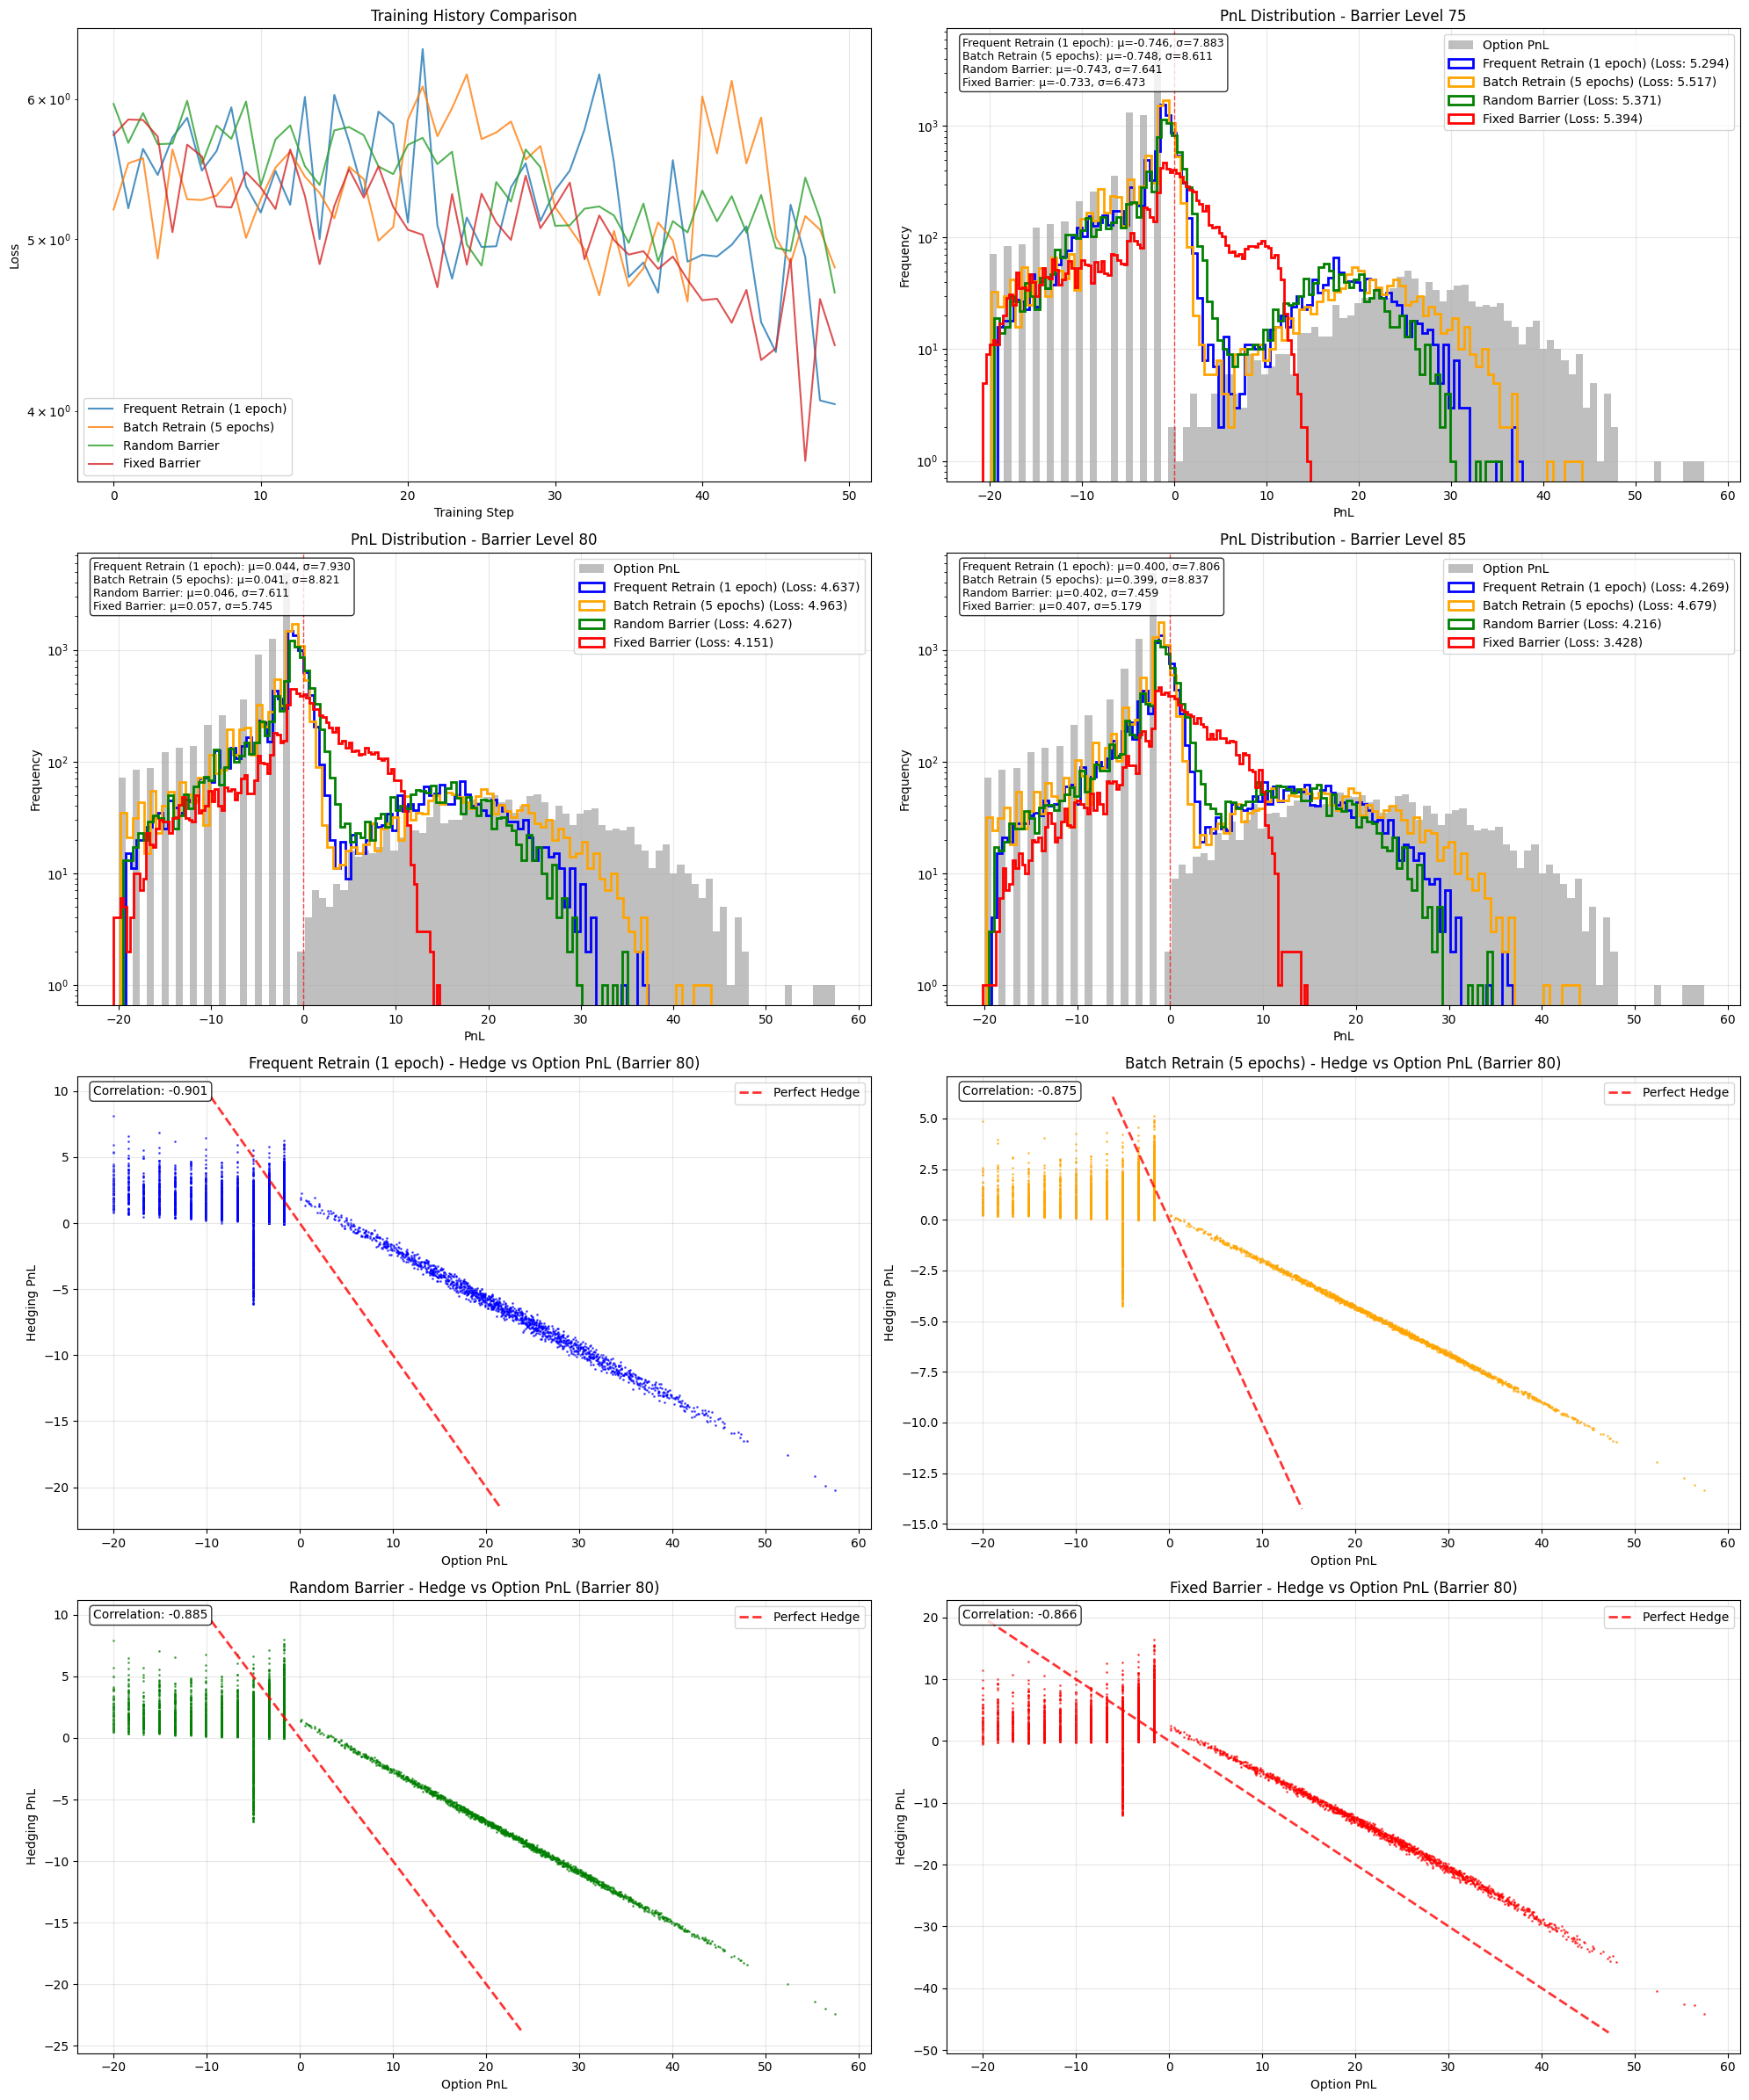


PnL Analysis Summary:

Barrier Level: 75
------------------------------
Frequent Retrain (1 epoch): Mean=-0.7457, Std= 7.8831, VaR95=-11.2748, Loss= 5.2943
Batch Retrain (5 epochs) : Mean=-0.7476, Std= 8.6113, VaR95=-11.5357, Loss= 5.5170
Random Barrier           : Mean=-0.7434, Std= 7.6414, VaR95=-11.7699, Loss= 5.3711
Fixed Barrier            : Mean=-0.7327, Std= 6.4728, VaR95=-14.2219, Loss= 5.3938

Barrier Level: 80
------------------------------
Frequent Retrain (1 epoch): Mean= 0.0437, Std= 7.9303, VaR95=-10.8091, Loss= 4.6368
Batch Retrain (5 epochs) : Mean= 0.0414, Std= 8.8206, VaR95=-11.5291, Loss= 4.9630
Random Barrier           : Mean= 0.0458, Std= 7.6105, VaR95=-11.0865, Loss= 4.6266
Fixed Barrier            : Mean= 0.0566, Std= 5.7453, VaR95=-11.6778, Loss= 4.1505

Barrier Level: 85
------------------------------
Frequent Retrain (1 epoch): Mean= 0.4002, Std= 7.8055, VaR95=-10.5588, Loss= 4.2692
Batch Retrain (5 epochs) : Mean= 0.3995, Std= 8.8367, VaR95=-11.5190, Loss= 4

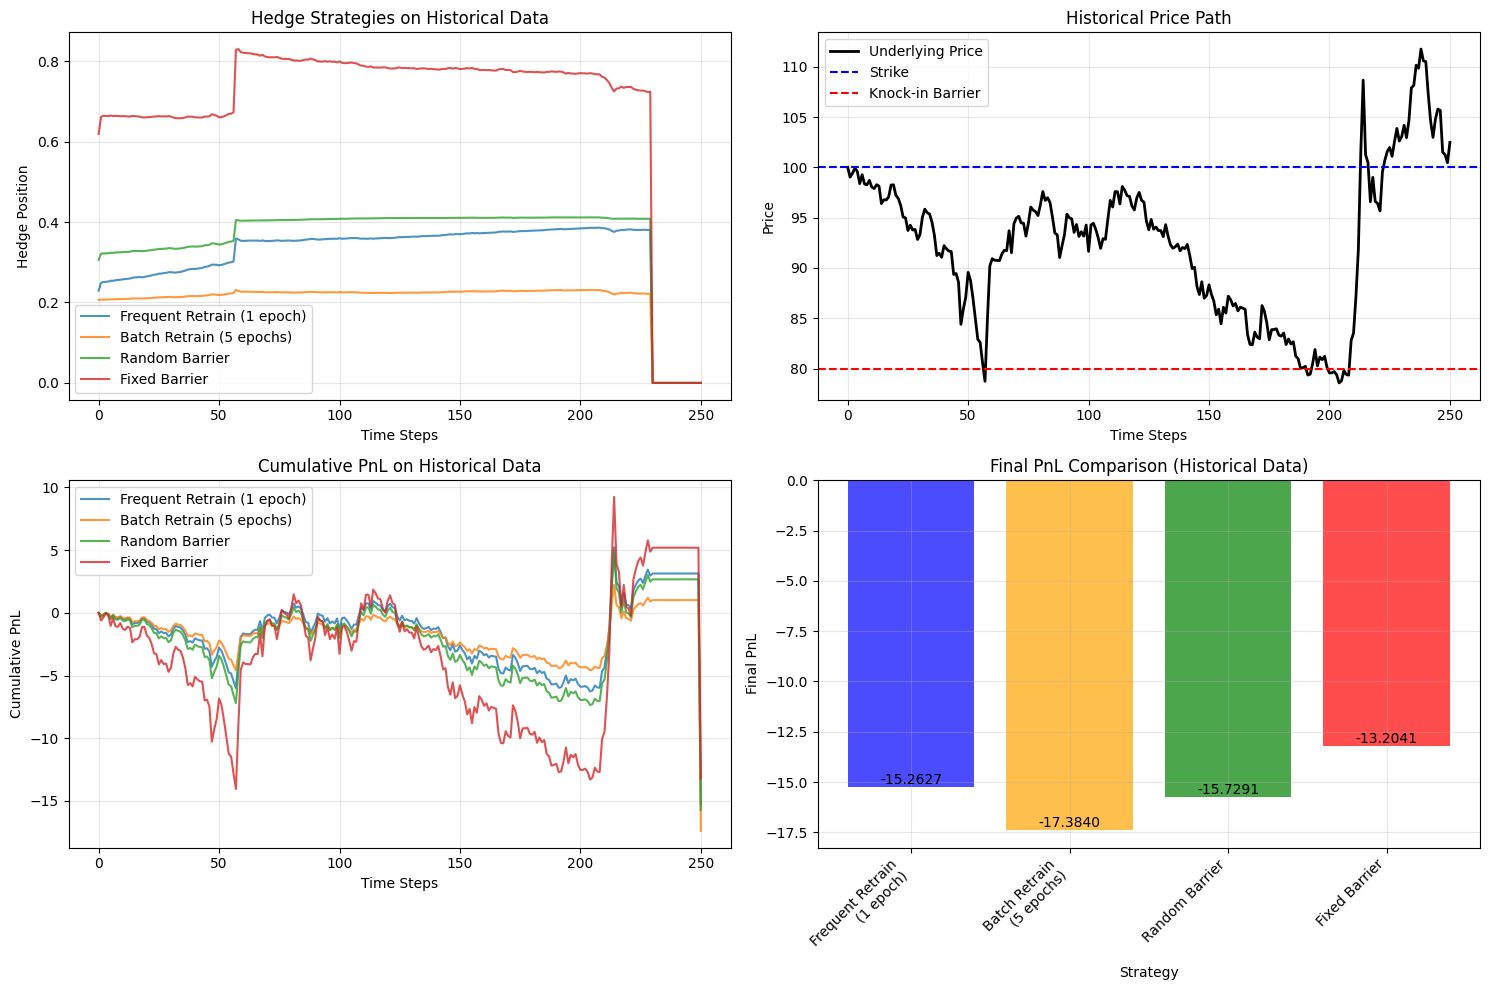


Historical Data Performance Summary:
----------------------------------------
Frequent Retrain (1 epoch): Final PnL = -15.262727
Batch Retrain (5 epochs): Final PnL = -17.383976
Random Barrier: Final PnL = -15.729074
Fixed Barrier: Final PnL = -13.204085


In [5]:
def retraining_strategies_experiment():
    """Experiment with different retraining strategies."""

    print("Retraining Strategies Experiment")
    print("=" * 50)

    # Load real market data
    try:
        quotes = pd.read_csv("000905.csv")
        series = torch.tensor(quotes["Close"].values, dtype=torch.float)[:-65]
        fixed_stock = FixedStock(spots=list(series), cost=1e-4, dt=1/250)
        his_vol = fixed_stock.volatility
        print(f"Loaded market data - Historical volatility: {his_vol:.6f}")
    except:
        print("Market data not available, using synthetic data")
        series = torch.randn(1000).cumsum(0).exp()
        fixed_stock = FixedStock(spots=list(series), cost=1e-4, dt=1/250)
        his_vol = 0.2

    # Training parameters
    train_seed = 888
    n_paths = 1000
    total_n_epochs = 50  # Reduced for demonstration

    # Market setup
    init_state = 100.0
    dt = 1 / 250
    sigma = 0.21
    mu = 0.0
    cost = 1e-4
    obs_days = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 230, 250]

    loss = ExpectedShortfall(0.5)

    features = [
        "log_moneyness",
        "expiry_time",
        "volatility",
        "knocked_in",
        "knockin_barrier_to_strike",
        "prev_hedge",
    ]

    def create_snowball(ki_barrier, underlier=None):
        if underlier is None:
            underlier = BrownianStock(sigma=sigma, mu=mu, dt=dt, cost=cost)
        return Snowball(
            underlier=underlier,
            notional=100,
            init_spot=init_state,
            strike=100.0,
            maturity=obs_days[-1] * dt,
            knockin_barrier=ki_barrier,
            observations=[d * dt for d in obs_days],
            knockout_barriers=[100.0] * len(obs_days),
            knockout_coupons=[0.2 * d / 250 for d in obs_days],
            no_touch_coupon=0.05,
            is_knocked_in=False,
        )

    def create_hedger():
        return Hedger(
            MultiLayerPerceptron(n_layers=4, n_units=[32, 32, 32, 32]),
            features,
            criterion=loss,
        )

    # Strategy 1: Frequent retraining with 1 epoch per barrier
    def retrain_frequent(n_epochs_per_retrain, n_retrains):
        torch.manual_seed(train_seed)
        history = []
        hedger = create_hedger()
        ki_barriers = torch.rand(n_retrains) * 20 + 70

        progress = tqdm(range(n_retrains), desc="Frequent Retraining")
        for i in progress:
            derivative = create_snowball(ki_barriers[i].item())
            h = hedger.fit(
                derivative,
                n_epochs=n_epochs_per_retrain,
                n_paths=n_paths,
                init_state=(init_state,),
                verbose=False,
            )
            progress.set_description(f"Retrain {i+1}/{n_retrains}, Loss={h[-1]:.4f}")
            history.extend(h)

        return hedger, history

    # Strategy 2: Batch retraining with higher epochs
    def retrain_batch(n_epochs_per_retrain, n_retrains):
        torch.manual_seed(train_seed)
        history = []
        hedger = create_hedger()
        ki_barriers = torch.rand(n_retrains) * 20 + 70

        progress = tqdm(range(n_retrains), desc="Batch Retraining")
        for i in progress:
            derivative = create_snowball(ki_barriers[i].item())
            h = hedger.fit(
                derivative,
                n_epochs=n_epochs_per_retrain,
                n_paths=n_paths,
                init_state=(init_state,),
                verbose=False,
            )
            progress.set_description(f"Batch {i+1}/{n_retrains}, Loss={h[-1]:.4f}")
            history.extend(h)

        return hedger, history

    # Strategy 3: Random barrier training
    def train_random_barrier():
        torch.manual_seed(train_seed)
        derivative = create_snowball(lambda x: torch.rand(x) * 20 + 70)
        hedger = create_hedger()
        history = hedger.fit(
            derivative, n_epochs=total_n_epochs, n_paths=n_paths, init_state=(init_state,)
        )
        return hedger, history

    # Strategy 4: Fixed barrier training
    def train_fixed_barrier():
        torch.manual_seed(train_seed)
        derivative = create_snowball(80.0)
        features_fixed = [f for f in features if f != "knockin_barrier_to_strike"]
        hedger = Hedger(
            MultiLayerPerceptron(n_layers=4, n_units=[32, 32, 32, 32]),
            features_fixed,
            criterion=loss,
        )
        history = hedger.fit(
            derivative, n_epochs=total_n_epochs, n_paths=n_paths, init_state=(init_state,)
        )
        return hedger, history

    print("Training different strategies...")

    # Execute strategies
    hedger_retrain_1, history_retrain_1 = retrain_frequent(1, total_n_epochs)
    hedger_retrain_10, history_retrain_10 = retrain_batch(5, total_n_epochs // 5)
    hedger_random, history_random = train_random_barrier()
    hedger_fixed, history_fixed = train_fixed_barrier()

    strategies = {
        "Frequent Retrain (1 epoch)": (hedger_retrain_1, history_retrain_1),
        "Batch Retrain (5 epochs)": (hedger_retrain_10, history_retrain_10),
        "Random Barrier": (hedger_random, history_random),
        "Fixed Barrier": (hedger_fixed, history_fixed),
    }

    # Test hedgers on different barrier levels for PnL analysis
    print("\nTesting hedgers on different barrier levels...")
    print("-" * 50)

    test_seed = 123
    test_n_paths = 10000
    test_ki_barriers = [75, 80, 85]
    init_spot = torch.tensor(init_state, requires_grad=True)

    def test_hedger_pnl(hedger, ki_barrier):
        """Test hedger performance for a specific barrier level."""
        with torch.no_grad():
            torch.manual_seed(test_seed)
            derivative_test = create_snowball(ki_barrier)
            derivative_test.simulate(n_paths=test_n_paths, init_state=(init_spot,))

            option_pnl = -derivative_test.payoff()
            hedge_pnl = hedger.compute_portfolio(derivative_test)
            total_pnl = hedger.compute_pl(derivative_test)

            return (
                total_pnl.detach().numpy(),
                option_pnl.detach().numpy(),
                hedge_pnl.detach().numpy(),
                loss(total_pnl).detach().item()
            )

    # Collect PnL data for all strategies and barrier levels
    pnl_data = {}
    option_pnl_data = {}
    hedge_pnl_data = {}
    loss_data = {}

    strategy_names = list(strategies.keys())
    hedgers_list = [strategies[name][0] for name in strategy_names]

    for barrier in test_ki_barriers:
        print(f"Testing barrier level: {barrier}")
        results = []
        for i, hedger in enumerate(hedgers_list):
            try:
                pnl, opt_pnl, hdg_pnl, loss_val = test_hedger_pnl(hedger, barrier)
                results.append((pnl, opt_pnl, hdg_pnl, loss_val))
                print(f"  {strategy_names[i]}: Loss = {loss_val:.4f}")
            except Exception as e:
                print(f"  Error testing {strategy_names[i]} on barrier {barrier}: {e}")
                results.append((None, None, None, float('inf')))

        pnl_data[barrier] = [r[0] for r in results]
        option_pnl_data[barrier] = [r[1] for r in results]
        hedge_pnl_data[barrier] = [r[2] for r in results]
        loss_data[barrier] = [r[3] for r in results]

    # Create comprehensive PnL analysis plots
    fig, axes = plt.subplots(4, 2, figsize=(20, 24))
    axes = axes.flatten()

    # Plot 1: Training histories
    for name, (_, history) in strategies.items():
        axes[0].plot(history, label=name, alpha=0.8)
    axes[0].set_xlabel("Training Step")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training History Comparison")
    axes[0].legend()
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.3)

    # Plots 2-4: PnL distributions for each barrier level
    for idx, barrier in enumerate(test_ki_barriers):
        ax = axes[idx + 1]

        # Plot option PnL (baseline)
        if option_pnl_data[barrier][0] is not None:
            ax.hist(option_pnl_data[barrier][0], bins=100, alpha=0.5,
                   label="Option PnL", color='gray')

        # Plot each strategy's PnL
        colors = ['blue', 'orange', 'green', 'red']
        for i, (name, pnl) in enumerate(zip(strategy_names, pnl_data[barrier])):
            if pnl is not None:
                ax.hist(pnl, bins=100, histtype="step",
                       label=f"{name} (Loss: {loss_data[barrier][i]:.3f})",
                       color=colors[i], linewidth=2)

        ax.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=1)
        ax.set_xlabel("PnL")
        ax.set_ylabel("Frequency")
        ax.set_yscale('log')
        ax.set_title(f"PnL Distribution - Barrier Level {barrier}")
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Add statistics text
        stats_text = []
        for i, (name, pnl) in enumerate(zip(strategy_names, pnl_data[barrier])):
            if pnl is not None:
                mean_pnl = np.mean(pnl)
                std_pnl = np.std(pnl)
                stats_text.append(f"{name}: μ={mean_pnl:.3f}, σ={std_pnl:.3f}")

        ax.text(0.02, 0.98, '\n'.join(stats_text), transform=ax.transAxes,
                verticalalignment='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Plots 5-8: Scatter plots of hedging PnL vs option PnL (barrier 80 only)
    colors = ['blue', 'orange', 'green', 'red']
    for i, name in enumerate(strategy_names):
        ax = axes[i + 4]

        if (option_pnl_data[80][i] is not None and hedge_pnl_data[80][i] is not None):
            ax.scatter(option_pnl_data[80][i], hedge_pnl_data[80][i],
                      alpha=0.6, s=1, color=colors[i])
            ax.set_xlabel("Option PnL")
            ax.set_ylabel("Hedging PnL")
            ax.set_title(f"{name} - Hedge vs Option PnL (Barrier 80)")
            ax.grid(True, alpha=0.3)

            # Add perfect hedge line (hedge PnL = -option PnL)
            x_min, x_max = ax.get_xlim()
            y_min, y_max = ax.get_ylim()
            pts = np.array([max(x_min, -y_max), min(x_max, -y_min)])
            ax.plot(pts, -pts, 'r--', linewidth=2, alpha=0.8, label='Perfect Hedge')
            ax.legend()

            # Add correlation coefficient
            if len(option_pnl_data[80][i]) > 1:
                corr = np.corrcoef(option_pnl_data[80][i], hedge_pnl_data[80][i])[0, 1]
                ax.text(0.02, 0.98, f'Correlation: {corr:.3f}',
                       transform=ax.transAxes, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        else:
            ax.text(0.5, 0.5, f"No data for {name}",
                   transform=ax.transAxes, ha='center', va='center')
            ax.set_title(f"{name} - No Data Available")
            ax.set_xlabel("Option PnL")
            ax.set_ylabel("Hedging PnL")

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\nPnL Analysis Summary:")
    print("=" * 60)
    for barrier in test_ki_barriers:
        print(f"\nBarrier Level: {barrier}")
        print("-" * 30)
        for i, name in enumerate(strategy_names):
            pnl = pnl_data[barrier][i]
            loss_val = loss_data[barrier][i]
            if pnl is not None:
                mean_pnl = np.mean(pnl)
                std_pnl = np.std(pnl)
                var_95 = np.percentile(pnl, 5)  # 95% VaR
                print(f"{name:25}: Mean={mean_pnl:7.4f}, Std={std_pnl:7.4f}, "
                      f"VaR95={var_95:7.4f}, Loss={loss_val:7.4f}")
            else:
                print(f"{name:25}: No data available")
    print()

    # Test performance on historical data (simplified)
    print("Testing performance on historical market data...")
    init_spot = torch.tensor(init_state, requires_grad=True)
    test_derivative = create_snowball(80.0, underlier=fixed_stock)
    test_derivative.simulate(n_paths=1, init_state=(init_spot,))

    # Compute hedge paths for visualization
    hedge_paths = {}
    pnl_paths = {}

    for name, (hedger, _) in strategies.items():
        try:
            hedge = hedger.compute_hedge(test_derivative).squeeze()
            pnl = hedger.compute_cum_pl(test_derivative).squeeze()

            hedge_paths[name] = hedge.detach().numpy()
            pnl_paths[name] = pnl.detach().numpy()
        except Exception as e:
            print(f"Error computing hedge for {name}: {e}")

    # Plot historical performance
    spots = test_derivative.ul().spot.squeeze().detach().numpy()

    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    for name, hedge in hedge_paths.items():
        plt.plot(hedge, label=name, alpha=0.8)
    plt.xlabel("Time Steps")
    plt.ylabel("Hedge Position")
    plt.title("Hedge Strategies on Historical Data")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 2)
    plt.plot(spots, label="Underlying Price", color='black', linewidth=2)
    plt.axhline(y=100, color='blue', linestyle='--', label='Strike')
    plt.axhline(y=80, color='red', linestyle='--', label='Knock-in Barrier')
    plt.xlabel("Time Steps")
    plt.ylabel("Price")
    plt.title("Historical Price Path")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 3)
    for name, pnl in pnl_paths.items():
        plt.plot(pnl, label=name, alpha=0.8)
    plt.xlabel("Time Steps")
    plt.ylabel("Cumulative PnL")
    plt.title("Cumulative PnL on Historical Data")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Final PnL comparison
    plt.subplot(2, 2, 4)
    final_pnls = [pnl[-1] for pnl in pnl_paths.values()]
    strategy_names_short = list(pnl_paths.keys())
    colors = ['blue', 'orange', 'green', 'red']

    bars = plt.bar(range(len(final_pnls)), final_pnls,
                   color=colors[:len(final_pnls)], alpha=0.7)
    plt.xlabel("Strategy")
    plt.ylabel("Final PnL")
    plt.title("Final PnL Comparison (Historical Data)")
    plt.xticks(range(len(strategy_names_short)),
               [name.replace(' (', '\n(') for name in strategy_names_short],
               rotation=45, ha='right')
    plt.grid(True, alpha=0.3)

    # Add value labels on bars
    for bar, value in zip(bars, final_pnls):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{value:.4f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

    # Summary statistics
    print("\nHistorical Data Performance Summary:")
    print("-" * 40)
    for name, pnl in pnl_paths.items():
        print(f"{name}: Final PnL = {pnl[-1]:.6f}")

    return strategies

# Run retraining strategies experiment
strategies_results = retraining_strategies_experiment()

## Key Insights from Retraining Strategies

### Training Approach Comparison
- **Frequent Retraining**: Provides adaptive learning but may be unstable
- **Batch Retraining**: Balances stability with adaptability
- **Random Barrier**: Offers robust generalization across scenarios
- **Fixed Barrier**: Simple but may lack flexibility for varying conditions

### Historical Data Performance
- **Hedge Adaptability**: How strategies respond to real market movements
- **PnL Stability**: Cumulative performance across the time series
- **Strategy Robustness**: Performance under different market regimes

### Practical Considerations
- **Computational Cost**: Trade-off between training frequency and performance
- **Market Regime Changes**: Need for adaptive training strategies
- **Risk Management**: Real-time monitoring and strategy adjustment

### Implementation Guidelines
- **Training Schedule**: Balance between adaptation and stability
- **Feature Selection**: Importance of robust feature sets
- **Performance Monitoring**: Continuous evaluation of hedge effectiveness

This experiment demonstrates the importance of training strategy selection for real-world implementation of Snowball hedging systems, highlighting the trade-offs between different approaches and their suitability for various market conditions.